CELL 1 — Import Libraries

In [3]:
# Libraries are pre-built tools that save us from writing everything ourselves

import pandas as pd          # for loading and working with data (like Excel in Python)
import numpy as np           # for math/number operations
import matplotlib.pyplot as plt  # for drawing charts
import seaborn as sns        # nicer-looking charts built on top of matplotlib
import warnings
warnings.filterwarnings('ignore')  # hide minor warnings so output looks cleaner

print("Libraries loaded!")

Libraries loaded!


CELL 2 — Load the Dataset

In [4]:
# pd.read_csv() reads a CSV file and stores it as a DataFrame (like a table)
df = pd.read_csv('/Telco_Cusomer_Churn.csv')

# .shape tells you (rows, columns)
print("Shape:", df.shape)

# .head() shows the first 5 rows
df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


CELL 3 — Understand Data

In [5]:
# .info() shows column names, data types, and non-null counts
df.info()

# .describe() gives statistics for number columns (mean, min, max, etc.)
df.describe()

# Check for missing values in each column
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


CELL 4 — Explore the Target Column (Churn)

Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


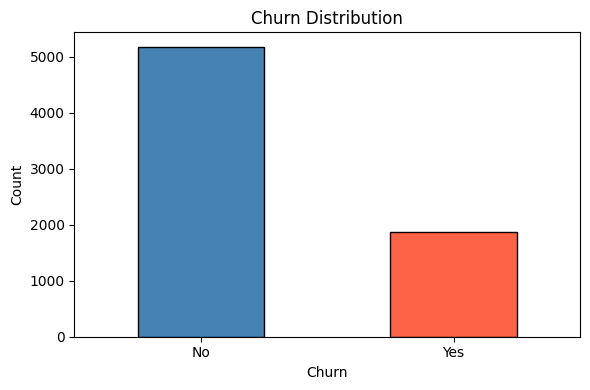

In [6]:
# Count how many Yes/No in the Churn column
print(df['Churn'].value_counts())
print(df['Churn'].value_counts(normalize=True) * 100)  # as percentages

# Visualise it
plt.figure(figsize=(6, 4))
df['Churn'].value_counts().plot(kind='bar', color=['steelblue', 'tomato'], edgecolor='black')
plt.title('Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

CELL 5 — Explore Key Features (EDA)

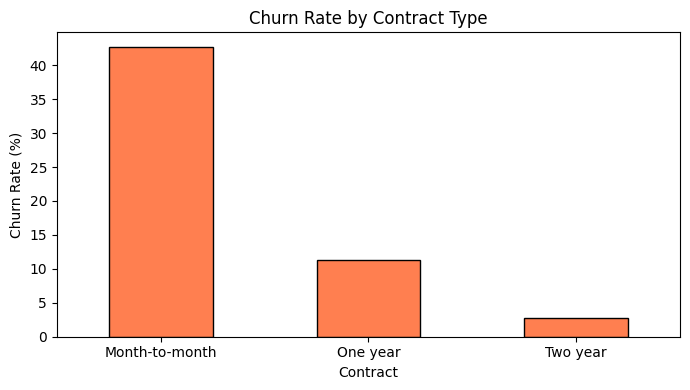

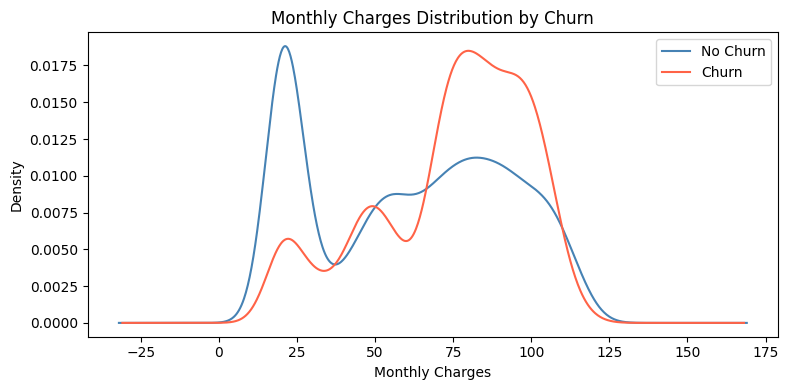

In [7]:
# Churn rate by Contract type — one of the strongest predictors for a linear model
plt.figure(figsize=(7, 4))
contract_churn = df.groupby('Contract')['Churn'].apply(lambda x: (x == 'Yes').mean() * 100)
contract_churn.plot(kind='bar', color='coral', edgecolor='black')
plt.title('Churn Rate by Contract Type')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Distribution of MonthlyCharges vs Churn
plt.figure(figsize=(8, 4))
df[df['Churn'] == 'No']['MonthlyCharges'].plot(kind='kde', label='No Churn', color='steelblue')
df[df['Churn'] == 'Yes']['MonthlyCharges'].plot(kind='kde', label='Churn', color='tomato')
plt.title('Monthly Charges Distribution by Churn')
plt.xlabel('Monthly Charges')
plt.legend()
plt.tight_layout()
plt.show()

CELL 6 — Fix TotalCharges

In [9]:
# TotalCharges is stored as text (object), convert it to number
# Any blank/empty string becomes NaN automatically
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Check how many NaN appeared
print("Missing TotalCharges:", df["TotalCharges"].isnull().sum())

# These rows are new customers (tenure = 0, never been billed), so we fill with 0
df["TotalCharges"] = df["TotalCharges"].fillna(0)

print("After fix:", df["TotalCharges"].isnull().sum(), "missing values")
print("✅ TotalCharges fixed!")

Missing TotalCharges: 0
After fix: 0 missing values
✅ TotalCharges fixed!


CELL 7 — Drop customerID

In [10]:
# customerID is just a unique ID number, it doesn't help predict churn
# (worse — for a linear model it would even be misread as a giant numeric feature)
df = df.drop(columns=["customerID"])

print("New shape:", df.shape)
print("✅ customerID removed!")

New shape: (7043, 20)
✅ customerID removed!


CELL 8 — Encode Churn

In [11]:
# Machine learning models only understand numbers, not text
# So we convert: Yes -> 1, No -> 0
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

print(df["Churn"].value_counts())
print("✅ Churn encoded!")

Churn
0    5174
1    1869
Name: count, dtype: int64
✅ Churn encoded!


CELL 9 — Encode Text Columns

In [12]:
# Binary columns (only 2 possible values) -> simple 1/0 mapping
df["gender"] = df["gender"].map({"Male": 1, "Female": 0})
df["Partner"] = df["Partner"].map({"Yes": 1, "No": 0})
df["Dependents"] = df["Dependents"].map({"Yes": 1, "No": 0})
df["PhoneService"] = df["PhoneService"].map({"Yes": 1, "No": 0})
df["PaperlessBilling"] = df["PaperlessBilling"].map({"Yes": 1, "No": 0})

print("✅ Binary columns encoded!")

# Multi-value columns -> One-Hot Encoding
# This creates a new 0/1 column for each possible value. For Logistic Regression
# specifically this matters even more than for KNN: the model reads a raw integer
# category (e.g. DSL=0, Fiber=1, None=2) as an ORDERED, evenly-spaced quantity,
# which would attach a meaningless, misleading coefficient to it. One-hot avoids that.
multi_cols = [
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaymentMethod",
]

df = pd.get_dummies(df, columns=multi_cols, drop_first=True)

print("Shape after one-hot encoding:", df.shape)
print("✅ Text columns encoded!")

✅ Binary columns encoded!
Shape after one-hot encoding: (7043, 31)
✅ Text columns encoded!


## CELL 10 — Train/Test Split FIRST, Then Scale

**Why order matters:** if we scale (fit `StandardScaler`) on the whole dataset and *then* split into train/test, the scaler has already "seen" the test rows when it computed its mean/std. That's data leakage — the test set is supposed to be completely untouched until evaluation.

This matters **more** for Logistic Regression than for most models: the regularization penalty (`C`) shrinks coefficients based on their scaled magnitude, so if the scaler leaked test-set information into the mean/std it uses, the regularization strength itself would be quietly biased.

So we split first, fit the scaler on `X_train` only, then use that same fitted scaler to transform `X_test`. This matches `shared/preprocessing.py`, which the other members' scripts rely on.

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# X = all columns except Churn (the inputs), y = Churn (what we predict)
X = df.drop(columns=["Churn"])
y = df["Churn"]

# Split BEFORE scaling — stratify=y keeps the same 73/27 churn ratio in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Fit the scaler on TRAIN ONLY, then apply it to both — no leakage
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

print(f"Training set:  {X_train.shape[0]} rows")
print(f"Test set:      {X_test.shape[0]} rows")
print(f"Features:      {X_train.shape[1]}")
print("✅ Split + scaling done, no leakage!")

Training set:  5634 rows
Test set:      1409 rows
Features:      30
✅ Split + scaling done, no leakage!


## CELL 11 — What Does Logistic Regression Actually Do?

Unlike KNN (which just votes among nearby neighbors), Logistic Regression **learns a formula**. It:

1. Multiplies every feature by a learned weight, and adds them all up (a "weighted sum") — exactly like ordinary linear regression: `z = w1*x1 + w2*x2 + ... + b`
2. Passes that sum `z` through the **sigmoid function**, which squashes any number into a probability between 0 and 1: `sigmoid(z) = 1 / (1 + e^-z)`
3. If that probability is >= 0.5, predicts Churn; otherwise predicts No Churn
4. During training, it adjusts the weights to minimize how wrong its probabilities are (log-loss), typically nudging weights up for features that tend to occur alongside churn, and down for features that tend to occur alongside staying

Below is a small demo of the sigmoid curve itself — the S-shaped function every prediction passes through, no matter how many features feed into `z`.

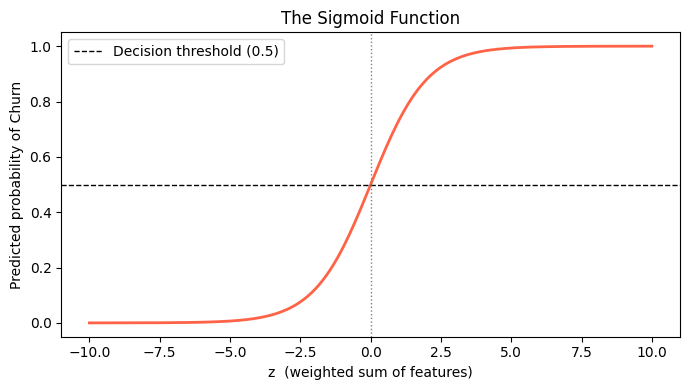

z = -5  ->  probability = 0.0067
z =  0  ->  probability = 0.5
z =  5  ->  probability = 0.9933


In [14]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

z_values = np.linspace(-10, 10, 200)
probabilities = sigmoid(z_values)

plt.figure(figsize=(7, 4))
plt.plot(z_values, probabilities, color="tomato", linewidth=2)
plt.axhline(0.5, color="black", linestyle="--", linewidth=1, label="Decision threshold (0.5)")
plt.axvline(0, color="gray", linestyle=":", linewidth=1)
plt.xlabel("z  (weighted sum of features)")
plt.ylabel("Predicted probability of Churn")
plt.title("The Sigmoid Function")
plt.legend()
plt.tight_layout()
plt.show()

print("z = -5  ->  probability =", round(sigmoid(-5), 4))
print("z =  0  ->  probability =", round(sigmoid(0), 4))
print("z =  5  ->  probability =", round(sigmoid(5), 4))

## CELL 12 — Why Scaling Matters for Logistic Regression

Logistic Regression usually trains with **regularization** (the `C` parameter), which penalizes large weights to avoid overfitting. That penalty is applied the *same way* to every feature's weight — it has no idea that `TotalCharges` is naturally in the thousands while `SeniorCitizen` is just 0 or 1.

If features were left unscaled, the model would need a *tiny* weight on `TotalCharges` and a *comparatively huge* weight on `SeniorCitizen` just to have equal real-world influence — and regularization would unfairly crush the small-scale feature's weight while barely touching the large-scale one. Scaling with `StandardScaler` puts every numeric feature on the same footing before regularization ever sees them. (The one-hot columns are already 0/1, so they're already comparable.)

## CELL 13 — Train a Baseline Logistic Regression Model

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report

# class_weight="balanced" re-weights the loss to account for the ~73/27 imbalance,
# without needing to resample the data or manually shift the decision threshold
logreg_model = LogisticRegression(C=1.0, class_weight="balanced", max_iter=2000, random_state=42)
logreg_model.fit(X_train, y_train)

logreg_pred = logreg_model.predict(X_test)

logreg_accuracy = accuracy_score(y_test, logreg_pred)
logreg_f1 = f1_score(y_test, logreg_pred)

print(f"Logistic Regression (C=1.0) Accuracy: {logreg_accuracy:.4f}")
print(f"Logistic Regression (C=1.0) F1 score: {logreg_f1:.4f}")
print("---")
print(classification_report(y_test, logreg_pred, target_names=["No Churn", "Churn"]))
print("✅ Baseline Logistic Regression done!")

Logistic Regression (C=1.0) Accuracy: 0.7381
Logistic Regression (C=1.0) F1 score: 0.6136
---
              precision    recall  f1-score   support

    No Churn       0.90      0.72      0.80      1035
       Churn       0.50      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409

✅ Baseline Logistic Regression done!


## CELL 14 — How Does Performance Change With `C`?

`C` is the main knob for Logistic Regression — it's the **inverse** of regularization strength. A very small `C` (e.g. 0.001) applies heavy regularization and shrinks weights toward 0, which can *underfit*. A very large `C` (e.g. 100) applies almost no regularization, letting the model fit the training data closely, which can *overfit*. Let's sweep across a range of `C` values and look at both **accuracy** and **F1** (F1 matters more here since churn is imbalanced ~27%/73%).

      C  Accuracy       F1
  0.001  0.731725 0.612705
  0.003  0.728886 0.605372
  0.010  0.738112 0.614420
  0.030  0.743790 0.618796
  0.100  0.743080 0.618143
  0.300  0.739532 0.615707
  1.000  0.738112 0.613613
  3.000  0.738112 0.613613
 10.000  0.737402 0.612971
 30.000  0.737402 0.612971
100.000  0.737402 0.612159


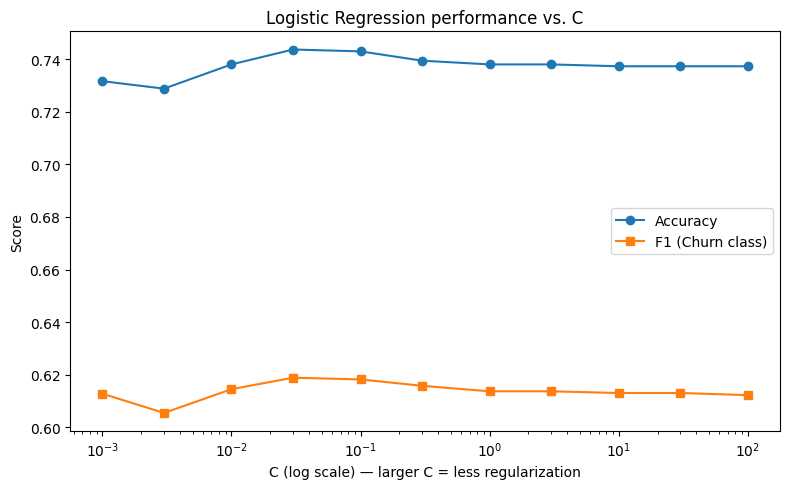


✅ Best C by F1 in this simple sweep: 0.03


In [16]:
C_values = [0.001, 0.003, 0.01, 0.03, 0.1, 0.3, 1, 3, 10, 30, 100]
acc_scores, f1_scores = [], []

for c in C_values:
    model = LogisticRegression(C=c, class_weight="balanced", max_iter=2000, random_state=42)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    acc_scores.append(accuracy_score(y_test, pred))
    f1_scores.append(f1_score(y_test, pred))

results_df = pd.DataFrame({"C": C_values, "Accuracy": acc_scores, "F1": f1_scores})
print(results_df.to_string(index=False))

plt.figure(figsize=(8, 5))
plt.plot(C_values, acc_scores, marker="o", label="Accuracy")
plt.plot(C_values, f1_scores, marker="s", label="F1 (Churn class)")
plt.xscale("log")
plt.xlabel("C (log scale) — larger C = less regularization")
plt.ylabel("Score")
plt.title("Logistic Regression performance vs. C")
plt.legend()
plt.tight_layout()
plt.show()

best_C = C_values[int(np.argmax(f1_scores))]
print(f"\n✅ Best C by F1 in this simple sweep: {best_C}")

## CELL 15 — L1 vs. L2 Penalty

There's a second knob besides `C`: the **penalty type**.

- **L2** ("ridge") shrinks every weight a little, but rarely zeroes any out
- **L1** ("lasso") can shrink some weights all the way to exactly 0 — effectively doing automatic feature selection

Not every solver supports both. `lbfgs` only supports L2; `liblinear` and `saga` support both. Mixing them up (e.g. asking `lbfgs` to do `L1`) throws a `ValueError` — this is exactly the bug the real training script's `build_param_grid()` guards against with two separate parameter dictionaries instead of one merged one. Here we just compare the two penalty types directly at the best `C` found above.

In [17]:
l2_model = LogisticRegression(
    C=best_C, penalty="l2", solver="liblinear", class_weight="balanced",
    max_iter=2000, random_state=42
)
l1_model = LogisticRegression(
    C=best_C, penalty="l1", solver="liblinear", class_weight="balanced",
    max_iter=2000, random_state=42
)

l2_model.fit(X_train, y_train)
l1_model.fit(X_train, y_train)

l2_f1 = f1_score(y_test, l2_model.predict(X_test))
l1_f1 = f1_score(y_test, l1_model.predict(X_test))
l1_zeroed = int((l1_model.coef_[0] == 0).sum())

print(f"L2 penalty  ->  F1: {l2_f1:.4f}")
print(f"L1 penalty  ->  F1: {l1_f1:.4f}  |  weights zeroed out: {l1_zeroed} / {X_train.shape[1]}")
print("✅ L1 vs L2 comparison done!")

L2 penalty  ->  F1: 0.6203
L1 penalty  ->  F1: 0.6173  |  weights zeroed out: 10 / 30
✅ L1 vs L2 comparison done!


## CELL 16 — Confusion Matrix & ROC Curve for the Best Setup Found Above

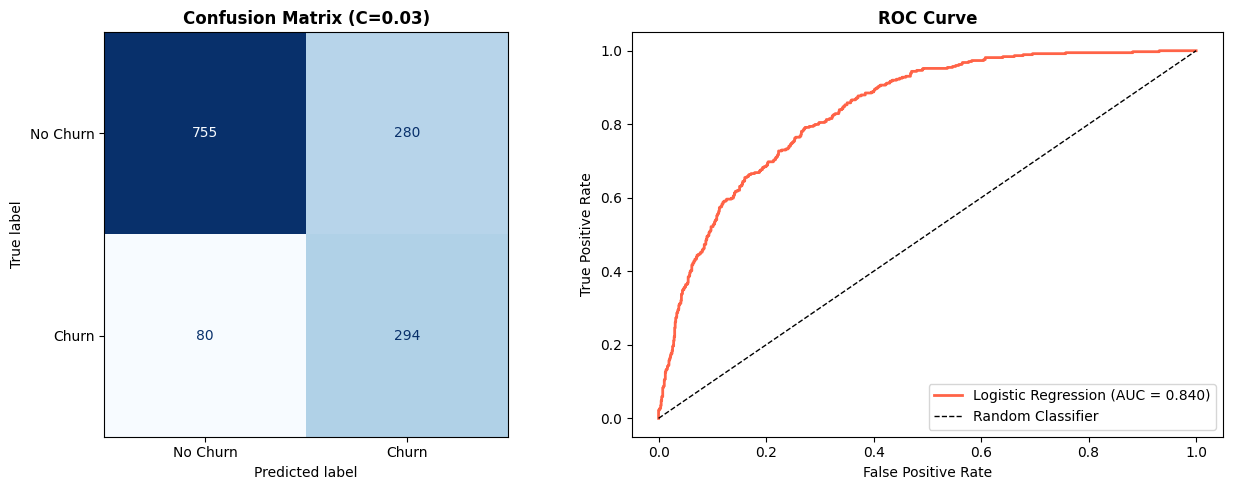

✅ Logistic Regression evaluation done!


In [18]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, roc_curve, roc_auc_score

best_logreg = LogisticRegression(
    C=best_C, penalty="l2", solver="liblinear", class_weight="balanced",
    max_iter=2000, random_state=42
)
best_logreg.fit(X_train, y_train)
best_pred = best_logreg.predict(X_test)
best_prob = best_logreg.predict_proba(X_test)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cm = confusion_matrix(y_test, best_pred)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Churn", "Churn"]).plot(
    ax=axes[0], colorbar=False, cmap="Blues"
)
axes[0].set_title(f"Confusion Matrix (C={best_C})", fontweight="bold")

fpr, tpr, _ = roc_curve(y_test, best_prob)
auc = roc_auc_score(y_test, best_prob)
axes[1].plot(fpr, tpr, linewidth=2, color="tomato", label=f"Logistic Regression (AUC = {auc:.3f})")
axes[1].plot([0, 1], [0, 1], "k--", linewidth=1, label="Random Classifier")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve", fontweight="bold")
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()
print("✅ Logistic Regression evaluation done!")

## CELL 17 — Coefficients & Odds Ratios

This is Logistic Regression's biggest advantage over KNN: every feature gets a single, readable number. A positive coefficient increases the log-odds of churn; a negative one decreases it. Exponentiating a coefficient turns it into an **odds ratio** — "for a one-unit increase in this (scaled) feature, the odds of churn are multiplied by X" — which is usually the more intuitive number to put in a report.

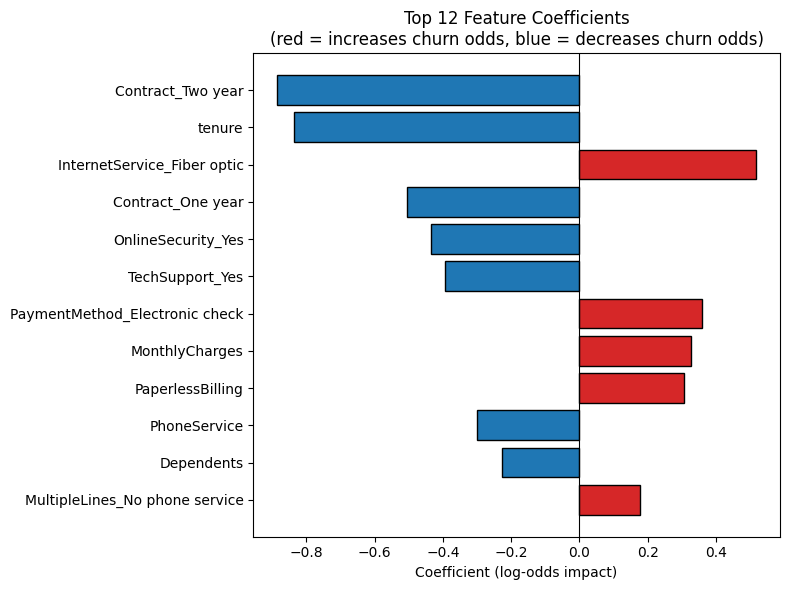

Odds ratios for the same top features:
InternetService_Fiber optic       1.678
PaymentMethod_Electronic check    1.433
MonthlyCharges                    1.387
PaperlessBilling                  1.360
MultipleLines_No phone service    1.194
Dependents                        0.798
PhoneService                      0.741
TechSupport_Yes                   0.674
OnlineSecurity_Yes                0.648
Contract_One year                 0.603
tenure                            0.433
Contract_Two year                 0.413
dtype: float64


In [19]:
coefs = pd.Series(best_logreg.coef_[0], index=X_train.columns)
top_coefs = coefs.reindex(coefs.abs().sort_values(ascending=False).index).head(12)

plt.figure(figsize=(8, 6))
colors = ["#d62728" if v > 0 else "#1f77b4" for v in top_coefs.values[::-1]]
plt.barh(top_coefs.index[::-1], top_coefs.values[::-1], color=colors, edgecolor="black")
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("Coefficient (log-odds impact)")
plt.title("Top 12 Feature Coefficients\n(red = increases churn odds, blue = decreases churn odds)")
plt.tight_layout()
plt.show()

odds_ratios = np.exp(top_coefs).sort_values(ascending=False)
print("Odds ratios for the same top features:")
print(odds_ratios.round(3))

## Notes — this notebook vs. `member2_LogisticRegression/train_logistic_regression.py`

This notebook is a **before-training sandbox** to build intuition for what Logistic Regression does and how sensitive it is to `C` and penalty type — it is *not* the model used in the app or the report.

The real, graded Logistic Regression model lives in `member2_LogisticRegression/train_logistic_regression.py`, and goes further than this notebook in three ways:

1. **Proper tuning** — `GridSearchCV` (5-fold, scored by F1) searches over `C`, `penalty`, and `solver` together, using a **list of two separate parameter dictionaries** (one for L2-compatible solvers, one for L1-compatible solvers) instead of the simple, one-knob-at-a-time sweeps above.
2. **Guard against the flattened-grid bug** — a diagnostic `assert` checks the grid structure at runtime, since an earlier version of this project accidentally merged the two dictionaries into one and silently produced 30 failed fits (`lbfgs` + `l1` is not a valid combination).
3. **Shared data** — it loads `shared/processed/` (the exact same train/test split every other member uses) via `load_processed_data()`, instead of re-doing the split here, so the final comparison in `results/compare_models.py` is fair.

Once you're comfortable with what's happening above, run the real thing:

```bash
python shared/preprocessing.py   # if not already run
python member2_LogisticRegression/train_logistic_regression.py
```